In [1]:
# Ensemble Learning : Bagging vs Boosting

In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
# Create a synthetic dataset
X, y = make_classification(
    n_samples=500,       # 500 data points
    n_features=10,       # 10 features
    n_informative=5,     # 5 informative features
    n_redundant=2,       # 2 redundant features
    n_classes=2,         # binary classification
    random_state=0
)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=0)

# Bagging Classifier
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  
    n_estimators=50,
    random_state=0
)
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

# Boosting Classifier
boost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1), 
    n_estimators=50,
    random_state=0
)
boost_model.fit(X_train, y_train)
y_pred_boost = boost_model.predict(X_test)
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Bagging Accuracy: 0.8666666666666667
Boosting Accuracy: 0.8266666666666667


In [3]:
# RANDOM FOREST

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = [[1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 8], [8, 9]]
y = [0, 0, 0, 1, 1, 1, 1, 1]   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) #build 5 decision trees
model = RandomForestClassifier(n_estimators=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Predictions:", y_pred)

Accuracy: 1.0
Predictions: [0 1 0]


Dataset Loaded Successfully
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450 

C:\Users\hp\AppData\Local\Temp\ipykernel_10156\1237329641.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)



Accuracy: 0.7910447761194029

Confusion Matrix:
 [[136  21]
 [ 35  76]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.87      0.83       157
           1       0.78      0.68      0.73       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268

OOB Score: 0.8186195826645265
Cross-Validation Score (Mean): 0.8193459293201932


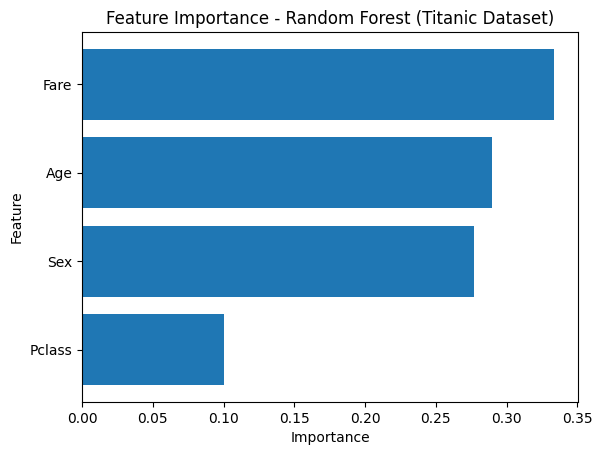

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Dataset Loaded Successfully")
print(df.head())

df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']]
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(
    n_estimators=100,       # number of trees
    oob_score=True,         # enable out-of-bag score
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("OOB Score:", model.oob_score_)

# Cross-Validation Score : unseen data (within your training set)
cv_score = cross_val_score(model, X, y, cv=5)
print("Cross-Validation Score (Mean):", cv_score.mean())

# Feature Importance Plot
importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest (Titanic Dataset)")
plt.show()

 Accuracy: 0.7532467532467533


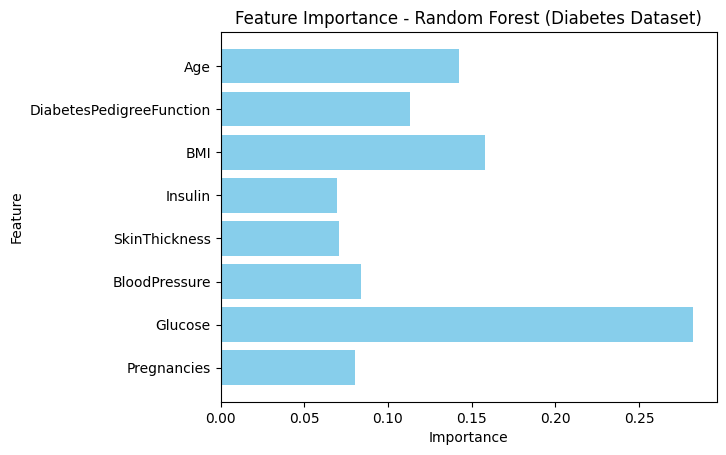

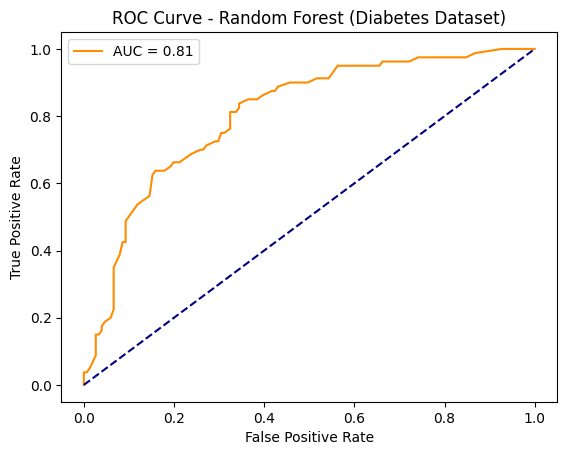

In [6]:
# TASK 12
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability for class 1

accuracy = accuracy_score(y_test, y_pred)
print(" Accuracy:", accuracy)

importances = model.feature_importances_   # Feature Importance
features = X.columns
plt.barh(features, importances, color='skyblue')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest (Diabetes Dataset)")
plt.show()

#  ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Diabetes Dataset)")
plt.legend()
plt.show()

In [7]:
# ADA BOOST

In [8]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = [
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7]
]
y = [0, 0, 0, 1, 1, 1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Using a decision stump (tree with depth=1) as the base learner
base_model = DecisionTreeClassifier(max_depth=1)
adaboost = AdaBoostClassifier(estimator=base_model, n_estimators=10, learning_rate=1.0, random_state=42) #0.01 to 2.0

adaboost.fit(X_train, y_train)
y_pred = adaboost.predict(X_test)
print("Predictions:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))

Predictions: [0 0]
Accuracy: 1.0


Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]
Accuracy: 1.0


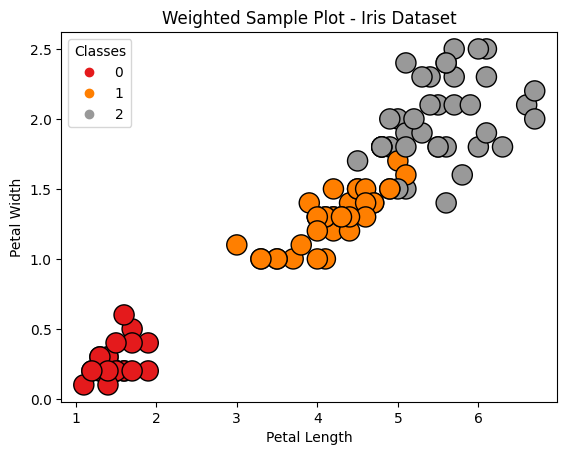

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
iris_df = pd.read_csv(url)

le = LabelEncoder()
y = le.fit_transform(iris_df['variety'])
X = iris_df[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

base_model = DecisionTreeClassifier(max_depth=1)
adaboost = AdaBoostClassifier(base_model, n_estimators=50, learning_rate=1.0, random_state=42)
adaboost.fit(X_train, y_train)
y_pred = adaboost.predict(X_test)
print("Predictions:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Weighted Sample Plot (using 2 features)
X_plot = X_train[:, [2,3]]  # petal.length, petal.width
sample_weights = np.ones(len(y_train)) / len(y_train) # initialize equal weights for each training sample.

scatter = plt.scatter(
    X_plot[:,0], X_plot[:,1],
    s=(sample_weights / max(sample_weights))*200 + 10,
    c=y_train,              
    cmap=plt.cm.Set1,       
    edgecolor='k'
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title("Weighted Sample Plot - Iris Dataset")

handles, labels = scatter.legend_elements(prop="colors")
plt.legend(handles, labels, title="Classes")

plt.show()

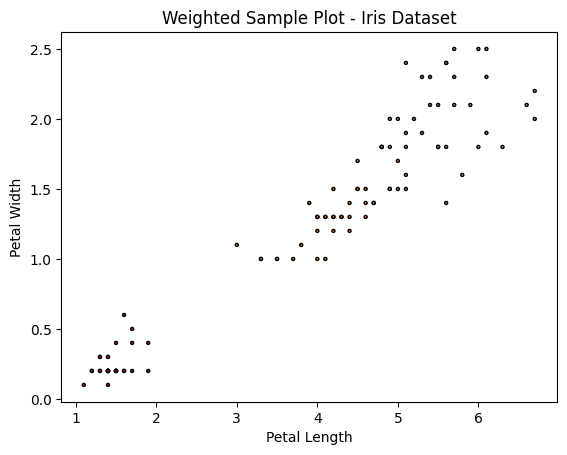

In [10]:
plt.scatter(
    X_plot[:,0], X_plot[:,1],
    s=sample_weights*500,
    c=y_train,
    cmap=plt.cm.Set1,
    edgecolor='k'
)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title("Weighted Sample Plot - Iris Dataset")
plt.show()

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

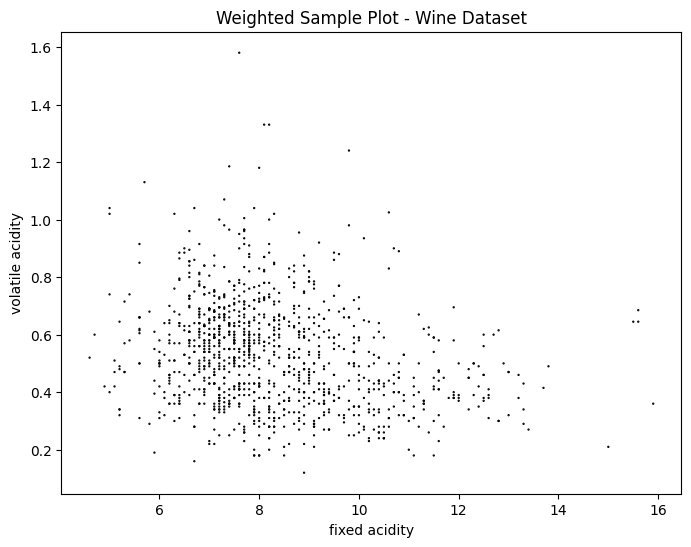

In [11]:
# TASK 13
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

url = "C:/Users/hp/Downloads/archive (11)/winequality-red.csv"
df = pd.read_csv(url)
print(df.head())
print(df.columns)

X = df.drop(['quality'], axis=1).values
y = df['quality'].values  # already numeric
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

base_model = DecisionTreeClassifier(max_depth=1)
adaboost = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
adaboost.fit(X_train, y_train)
y_pred = adaboost.predict(X_test)
print("Predictions:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Weighted Sample Plot (2 features for visualization) : # Using 'alcohol' and 'malic_acid' (first two columns)
X_plot = X_train[:, [0,1]]
sample_weights = np.ones(len(y_train)) / len(y_train)  # uniform for simplicity

plt.figure(figsize=(8,6))
plt.scatter(
    X_plot[:,0], X_plot[:,1],
    s=sample_weights*500,
    c=y_train,
    cmap=plt.cm.Set1,
    edgecolor='k'
)
plt.xlabel(df.columns[0])  # 'alcohol'
plt.ylabel(df.columns[1])  # 'malic_acid'
plt.title("Weighted Sample Plot - Wine Dataset")
plt.show()

In [12]:
# GRADIENT BOOSTING MACHINE

In [13]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

X, y = make_classification(
    n_samples=1000,    # total samples
    n_features=10,     # number of features
    n_informative=5,   # informative features
    n_redundant=2,     # redundant features
    n_classes=2,       # binary classification
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Gradient Boosting Classifier
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbm.fit(X_train, y_train)
y_pred = gbm.predict(X_test)
y_prob = gbm.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("ROC AUC Score:", roc_auc)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.96
ROC AUC Score: 0.9906655844155845
Confusion Matrix:
 [[108   4]
 [  4  84]]


   Diagnosis  feature_1  feature_2  feature_3  feature_4  feature_5  \
0          1      17.99      10.38     122.80     1001.0    0.11840   
1          1      20.57      17.77     132.90     1326.0    0.08474   
2          1      19.69      21.25     130.00     1203.0    0.10960   
3          1      11.42      20.38      77.58      386.1    0.14250   
4          1      20.29      14.34     135.10     1297.0    0.10030   

   feature_6  feature_7  feature_8  feature_9  ...  feature_21  feature_22  \
0    0.27760     0.3001    0.14710     0.2419  ...       25.38       17.33   
1    0.07864     0.0869    0.07017     0.1812  ...       24.99       23.41   
2    0.15990     0.1974    0.12790     0.2069  ...       23.57       25.53   
3    0.28390     0.2414    0.10520     0.2597  ...       14.91       26.50   
4    0.13280     0.1980    0.10430     0.1809  ...       22.54       16.67   

   feature_23  feature_24  feature_25  feature_26  feature_27  feature_28  \
0      184.60      2019.0  

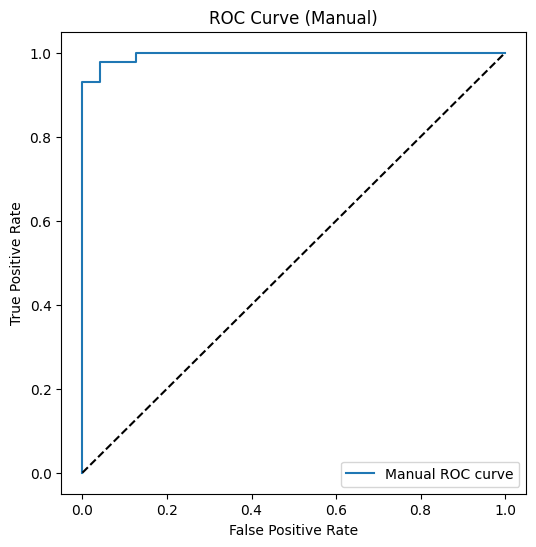

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

columns = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
df = pd.read_csv(url, header=None, names=columns)
df.drop('ID', axis=1, inplace=True)
df['Diagnosis'] = LabelEncoder().fit_transform(df['Diagnosis'])
print(df.head())
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Gradient Boosting model
gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)
y_prob = gbm.predict_proba(X_test)[:, 1] #[:, 1] selects the probability of being malignant(class1)
y_pred = gbm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance
feature_importance = pd.Series(gbm.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance:\n", feature_importance)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Manual ROC curve')
plt.plot([0,1], [0,1], 'k--')  # diagonal = random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Manual)')
plt.legend(loc='lower right')
plt.show()

Dataset loaded successfully!
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905  

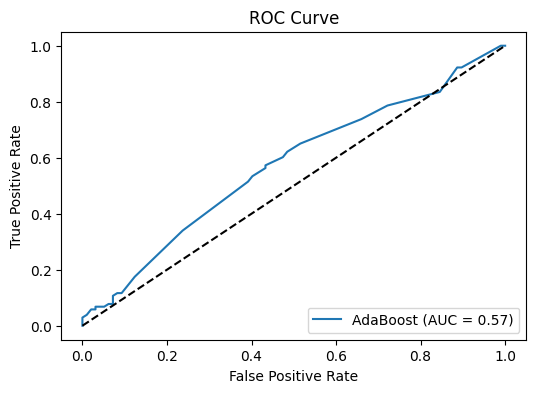

In [15]:
# TASK 14
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vnaumq/supermarket_sales/main/supermarket_sales.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully!")
print(df.head())

X = df.drop(['Invoice ID', 'Customer type', 'gross margin percentage', 'gross income', 'Rating', 'Total'], axis=1)
y = df['Customer type']   # Target: Member or Normal

# Encode categorical columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
y = LabelEncoder().fit_transform(y)  # Member=1, Normal=0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(n_estimators=100, learning_rate=0.8, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance:\n", importances)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AdaBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [16]:
# CLUSTERING
# 1. K MEAN CLUSTERING

In [17]:
from sklearn.cluster import KMeans
import numpy as np

# Sample data: 2 features (Age, Spending Score)
X = np.array([[25, 70],
              [30, 80],
              [35, 60],
              [40, 50],
              [45, 55],
              [50, 40],
              [55, 45],
              [60, 30]])

kmeans = KMeans(n_clusters=3, random_state=42) # with 3 clusters
kmeans.fit(X)
labels = kmeans.labels_ # Get cluster labels for each data point
centroids = kmeans.cluster_centers_ # Get coordinates of cluster centroids
print("Cluster Labels for each data point:", labels)
print("Centroids of the clusters:\n", centroids)

Cluster Labels for each data point: [2 2 0 0 0 1 1 1]
Centroids of the clusters:
 [[40.         55.        ]
 [55.         38.33333333]
 [27.5        75.        ]]


First 5 rows of dataset:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


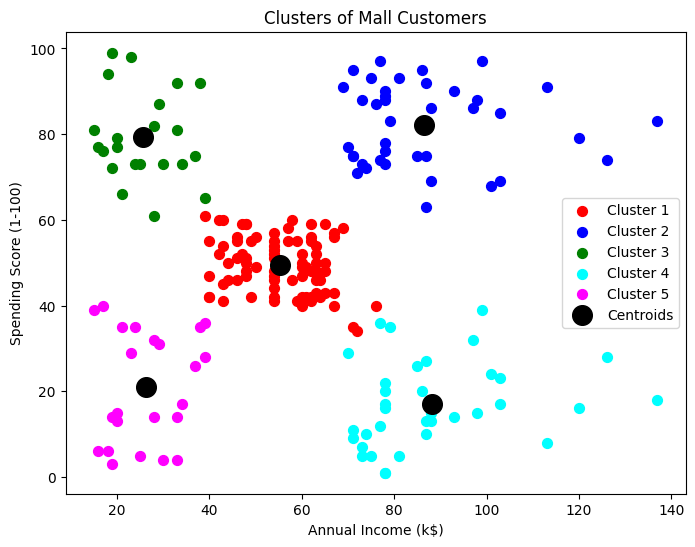


Cluster-wise mean values:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043

Centroids of each cluster:
Cluster 0 centroid -> Annual Income: 55.30, Spending Score: 49.52
Cluster 1 centroid -> Annual Income: 86.54, Spending Score: 82.13
Cluster 2 centroid -> Annual Income: 25.73, Spending Score: 79.36
Cluster 3 centroid -> Annual Income: 88.20, Spending Score: 17.11
Cluster 4 centroid -> Annual Income: 26.30, Spending Score: 20.91


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Mall_Customers.csv"
data = pd.read_csv(url)
print("First 5 rows of dataset:")
print(data.head())

X = data[['Annual Income (k$)', 'Spending Score (1-100)']] # Select features for clustering
kmeans = KMeans(n_clusters=5, init='k-means++',random_state=42)
y_kmeans = kmeans.fit_predict(X)
data['Cluster'] = y_kmeans # Add cluster assignment to the dataset

# Visualize the clusters
plt.figure(figsize=(8,6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(X.iloc[y_kmeans == i, 0], #plots first two features as x and y coordinates.
                X.iloc[y_kmeans == i, 1],
                s=50,
                c=colors[i],
                label=f'Cluster {i+1}')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200,
            c='black',
            label='Centroids')

plt.title('Clusters of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# Analyze cluster characteristics
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
print("\nCluster-wise mean values:")
cluster_means = data.groupby('Cluster')[numeric_cols].mean()
print(cluster_means)

# Centroids 
print("\nCentroids of each cluster:")
centroids = kmeans.cluster_centers_
for i, centroid in enumerate(centroids):
    print(f"Cluster {i} centroid -> Annual Income: {centroid[0]:.2f}, Spending Score: {centroid[1]:.2f}")

First 5 rows of Iris dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


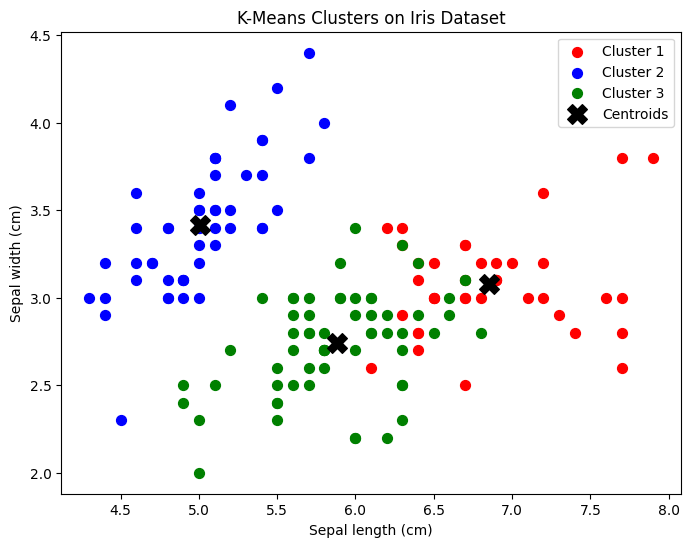


Centroids of each cluster:
Cluster 0 centroid -> Sepal length: 6.85, Sepal width: 3.08, Petal length: 5.72, Petal width: 2.05
Cluster 1 centroid -> Sepal length: 5.01, Sepal width: 3.42, Petal length: 1.46, Petal width: 0.24
Cluster 2 centroid -> Sepal length: 5.88, Sepal width: 2.74, Petal length: 4.39, Petal width: 1.43


In [19]:
# TASK 15
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import seaborn as sns

url = "https://gist.github.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv"
X = pd.read_csv(url)

print("First 5 rows of Iris dataset:")
print(X.head())

X_numeric = X.drop('species', axis=1)
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_numeric)
X['Cluster'] = y_kmeans

#Visualize clusters (first 2 features)
plt.figure(figsize=(8,6))
colors = ['red', 'blue', 'green']

for i in range(3):
    plt.scatter(X.iloc[y_kmeans == i, 0], X.iloc[y_kmeans == i, 1],
                s=50, c=colors[i], label=f'Cluster {i+1}')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids', marker='X')

plt.title('K-Means Clusters on Iris Dataset')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.legend()
plt.show()

print("\nCentroids of each cluster:")
centroids = kmeans.cluster_centers_
for i, centroid in enumerate(centroids):
    print(f"Cluster {i} centroid -> Sepal length: {centroid[0]:.2f}, Sepal width: {centroid[1]:.2f}, "
          f"Petal length: {centroid[2]:.2f}, Petal width: {centroid[3]:.2f}")

In [20]:
# 2.Hierarchical Clustering


--- Linkage method: single ---
Cluster assignments: [1 1 1 2 2 2]
Silhouette Score: 0.759
Davies-Bouldin Index: 0.258


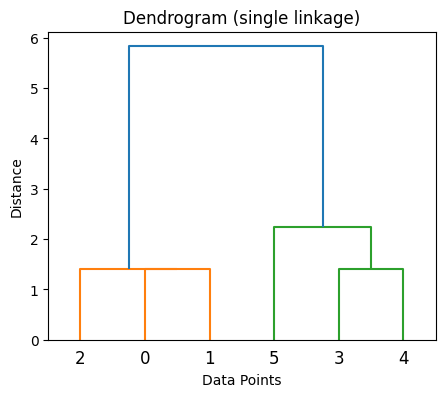

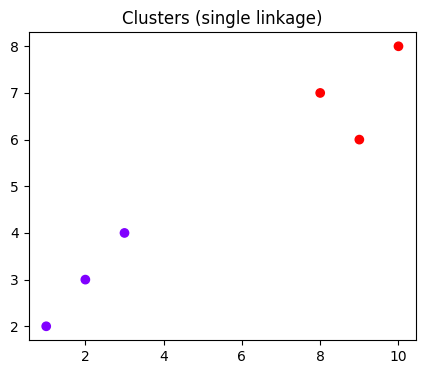


--- Linkage method: complete ---
Cluster assignments: [2 2 2 1 1 1]
Silhouette Score: 0.759
Davies-Bouldin Index: 0.258


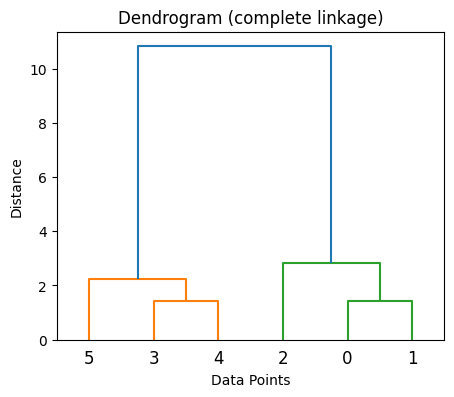

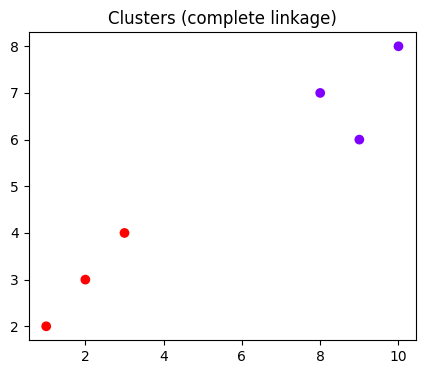


--- Linkage method: average ---
Cluster assignments: [1 1 1 2 2 2]
Silhouette Score: 0.759
Davies-Bouldin Index: 0.258


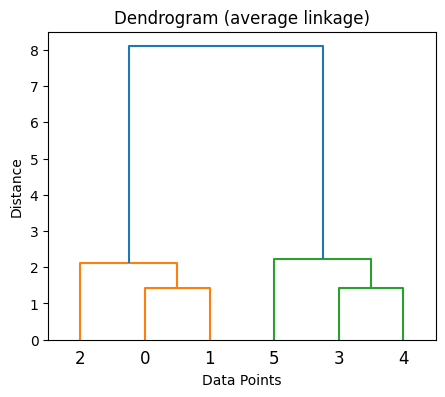

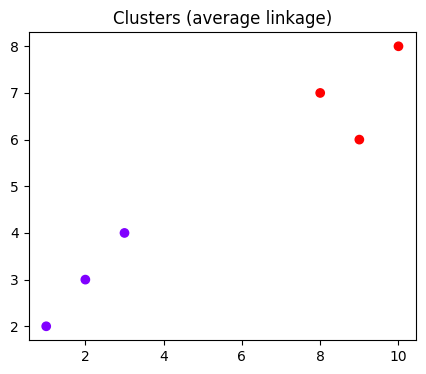


--- Linkage method: ward ---
Cluster assignments: [2 2 2 1 1 1]
Silhouette Score: 0.759
Davies-Bouldin Index: 0.258


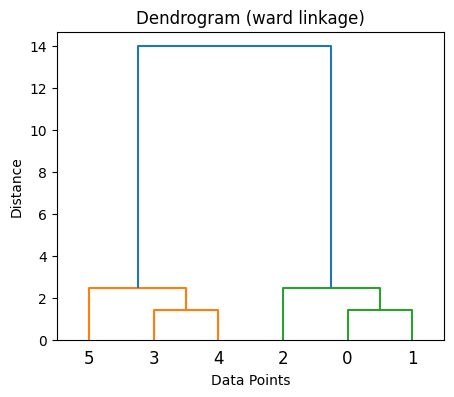

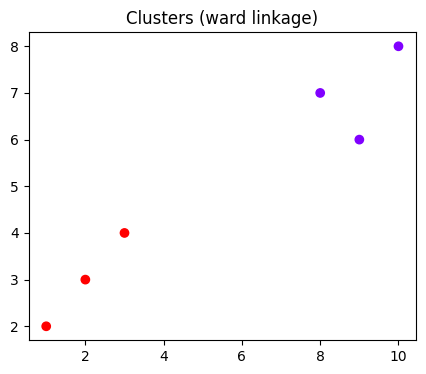

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score

X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [8, 7],
    [9, 6],
    [10, 8]
])
linkage_methods = ['single', 'complete', 'average', 'ward']

for method in linkage_methods:
    print(f"\n--- Linkage method: {method} ---")
    
    Z = linkage(X, method=method)  # Create linkage matrix
    clusters = fcluster(Z, t=2, criterion='maxclust')
    print("Cluster assignments:", clusters)
    
    sil_score = silhouette_score(X, clusters)
    db_score = davies_bouldin_score(X, clusters)
    print(f"Silhouette Score: {sil_score:.3f}")
    print(f"Davies-Bouldin Index: {db_score:.3f}")
    
    plt.figure(figsize=(5,4)) # Plot dendrogram
    dendrogram(Z)
    plt.title(f"Dendrogram ({method} linkage)")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.show()
    
    plt.figure(figsize=(5,4)) # Plot clustered data
    plt.scatter(X[:,0], X[:,1], c=clusters, cmap='rainbow')
    plt.title(f"Clusters ({method} linkage)")
    plt.show()


--- Linkage method: single ---
Cluster assignments (first 10): [3 2 5 2 2 2 2 2 2 2]
Silhouette Score: 0.003
Davies-Bouldin Index: 0.629


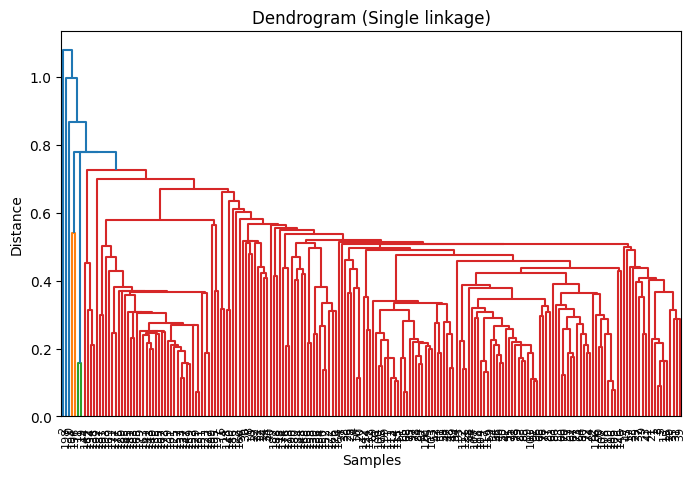

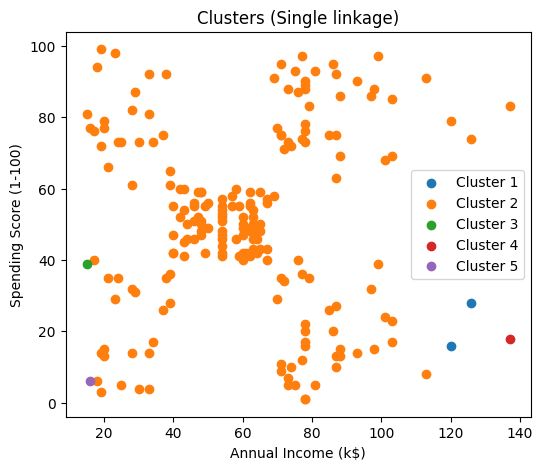


--- Linkage method: complete ---
Cluster assignments (first 10): [5 4 5 4 5 4 5 4 3 4]
Silhouette Score: 0.400
Davies-Bouldin Index: 0.885


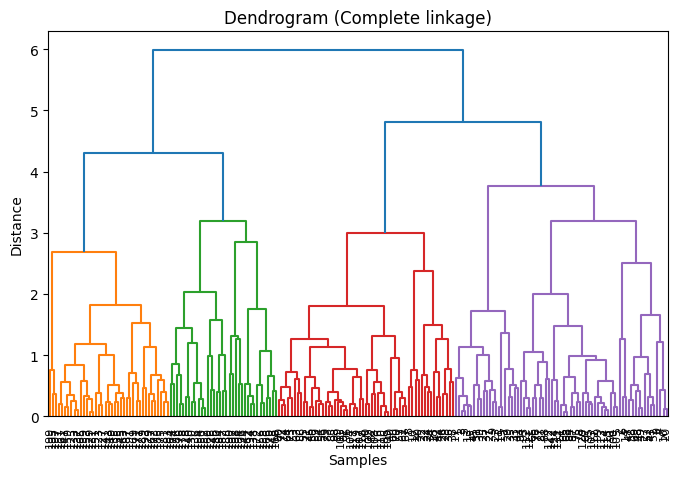

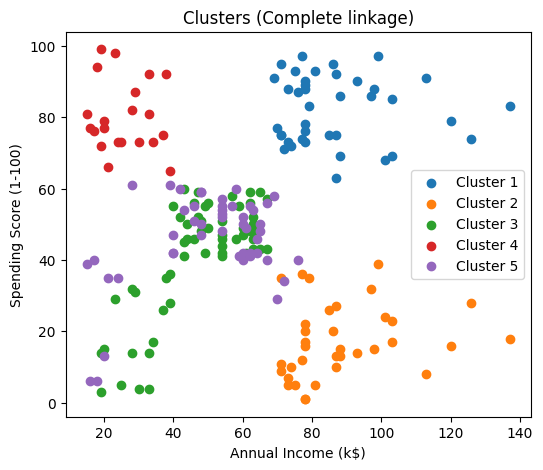


--- Linkage method: average ---
Cluster assignments (first 10): [5 2 5 2 5 2 5 2 5 2]
Silhouette Score: 0.410
Davies-Bouldin Index: 0.920


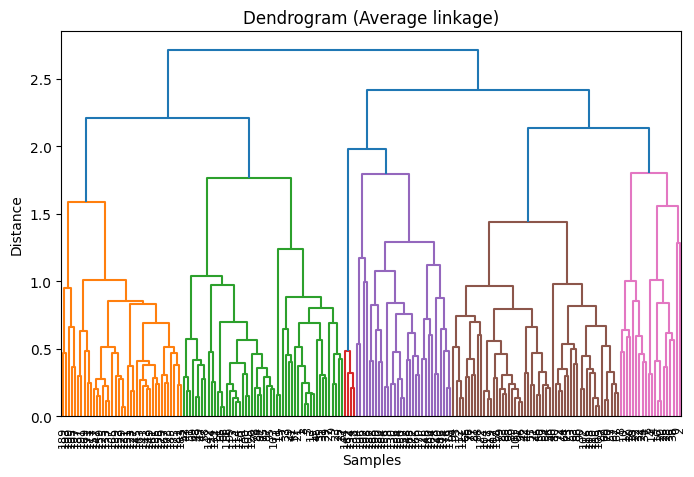

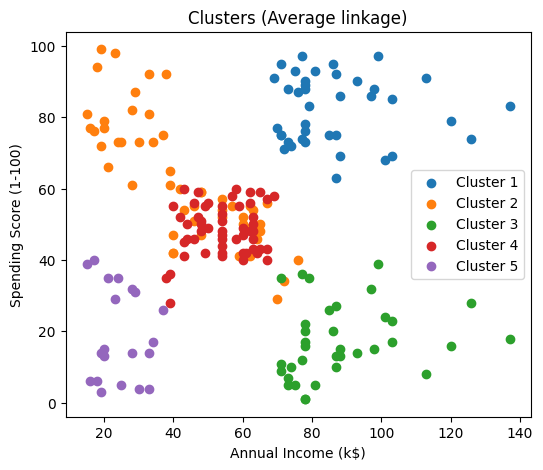


--- Linkage method: ward ---
Cluster assignments (first 10): [2 5 2 5 2 5 2 5 2 5]
Silhouette Score: 0.390
Davies-Bouldin Index: 0.916


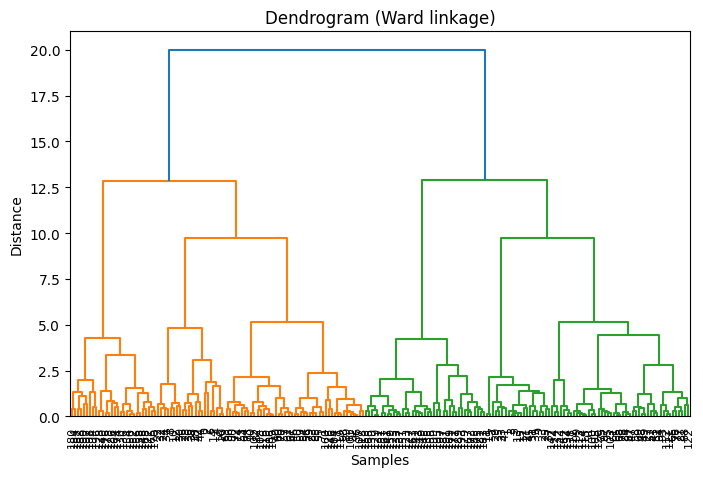

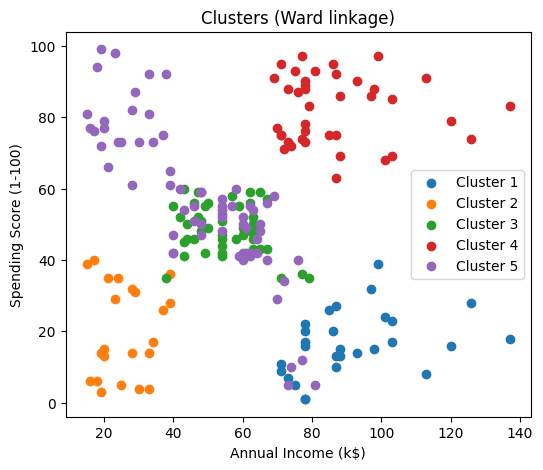

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

df = pd.read_csv("https://raw.githubusercontent.com/dphi-official/Datasets/master/Mall_Customers.csv")
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values  # Select numeric features for clustering

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

linkage_methods = ['single', 'complete', 'average', 'ward'] # linkage methods and number of clusters
n_clusters = 5

for method in linkage_methods:
    print(f"\n--- Linkage method: {method} ---")
    
    Z = linkage(X_scaled, method=method) # Compute linkage matrix
    
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust') # Assign clusters
    df[f'Cluster_{method}'] = clusters
    print("Cluster assignments (first 10):", clusters[:10])
    
    sil_score = silhouette_score(X_scaled, clusters) # Compute cluster evaluation metrics
    db_score = davies_bouldin_score(X_scaled, clusters)
    print(f"Silhouette Score: {sil_score:.3f}")
    print(f"Davies-Bouldin Index: {db_score:.3f}")
    
    # Plot dendrogram
    plt.figure(figsize=(8,5))
    dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
    plt.title(f"Dendrogram ({method.capitalize()} linkage)")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()
    
    # Plot clusters in 2D (Annual Income vs Spending Score)
    plt.figure(figsize=(6,5))
    for cluster_id in range(1, n_clusters+1):
        plt.scatter(
            X[clusters==cluster_id, 1],  # Annual Income
            X[clusters==cluster_id, 2],  # Spending Score
            label=f'Cluster {cluster_id}'
        )
    plt.title(f"Clusters ({method.capitalize()} linkage)")
    plt.xlabel("Annual Income (k$)")
    plt.ylabel("Spending Score (1-100)")
    plt.legend()
    plt.show()

Dataset Loaded Successfully
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.8              0.88         0.00             2.6      0.098   
1            7.8              0.76         0.04             2.3      0.092   
2           11.2              0.28         0.56             1.9      0.075   
3            7.4              0.70         0.00             1.9      0.076   
4            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 25.0                  67.0   0.9968  3.20       0.68   
1                 15.0                  54.0   0.9970  3.26       0.65   
2                 17.0                  60.0   0.9980  3.16       0.58   
3                 11.0                  34.0   0.9978  3.51       0.56   
4                 13.0                  40.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.8        5  
1      9.8    

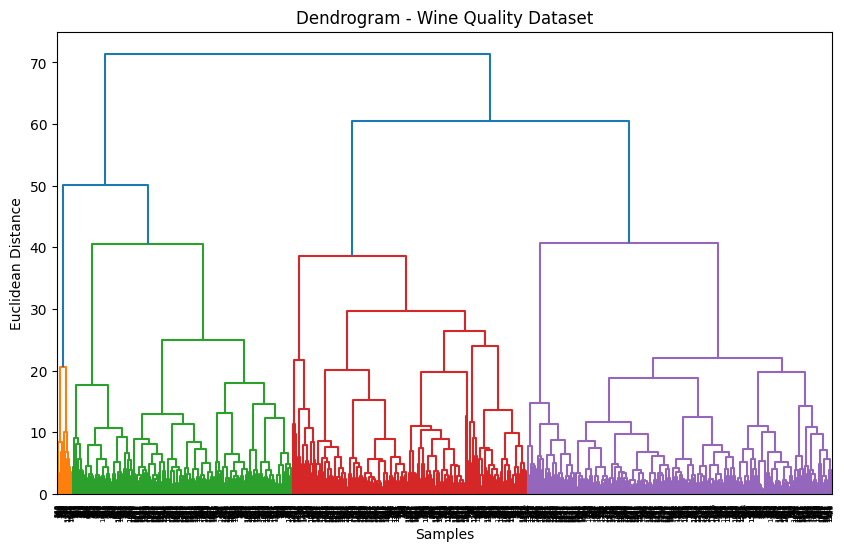

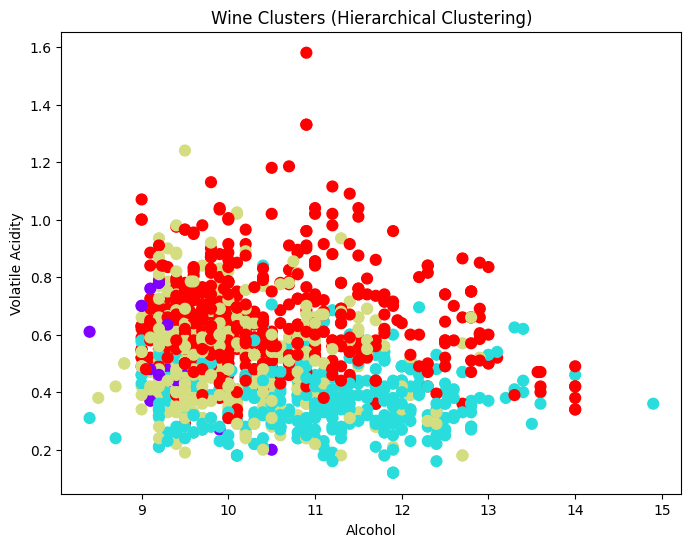

Silhouette Score: 0.171
Davies-Bouldin Index: 1.665


In [23]:
# TASK 16
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-red.csv"
df = pd.read_csv(url)
df.columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality']

print("Dataset Loaded Successfully")
print(df.head())
X = df.drop('quality', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Z = linkage(X_scaled, method='ward')

# Plot Dendrogram
plt.figure(figsize=(10, 6))
plt.title("Dendrogram - Wine Quality Dataset")
dendrogram(Z)
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

# Decide number of clusters
n_clusters = 4
clusters = fcluster(Z, n_clusters, criterion='maxclust')
df['Cluster'] = clusters # Add cluster labels

plt.figure(figsize=(8, 6)) # Visualize clusters
plt.scatter(df['alcohol'], df['volatile acidity'],
            c=df['Cluster'], cmap='rainbow', s=60)
plt.title('Wine Clusters (Hierarchical Clustering)')
plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.show()

# 11. Evaluate clusters
silhouette = silhouette_score(X_scaled, clusters)
db_score = davies_bouldin_score(X_scaled, clusters)
print(f"Silhouette Score: {silhouette:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")